# **Customer Churn Prediction (Classification project)**

## **Problem Statement**
Customer churn is a major concern for businesses, especially in the telecom industry. Losing customers leads to direct revenue loss and high acquisition costs for new users.
The goal of this project is to build a **Machine Learning classification model** that predicts whether a customer will leave the company (**Churn: Yes/No**) based on features like Tenure, Monthly Charges, Contract Type, and Internet Service.

In [1]:
# Task 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Task 2: Load the Dataset
data = pd.read_csv('telecom_churn_data.csv')
print("Dataset loaded successfully! Here is a quick peek:")
display(data.head())

Dataset loaded successfully! Here is a quick peek:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,NaN,Electronic check,70.70,151.65,Yes


In [3]:
# Task 3: Check Dataset (Shape, Columns, Data types, Summary statistics)
print("--- Shape ---")
print(data.shape, "\n")

print("--- Data Types ---")
print(data.dtypes, "\n")

# Notice that TotalCharges is an 'object' type but it should be numeric.
# We will fix this before running summary statistics.
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

print("--- Summary Statistics ---")
display(data.describe())

--- Shape ---
(7043, 21) 

--- Data Types ---
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object 

--- Summary Statistics ---


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7041.000000,7027.000000
mean,0.162147,32.371149,64.749581,2283.426918
std,0.368612,24.559481,30.085731,2267.250890
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.400000
50%,0.000000,29.000000,70.350000,1397.300000
75%,0.000000,55.000000,89.850000,3794.975000
max,1.000000,72.000000,118.750000,8684.800000


In [4]:
# Task 4: Handle Missing Values
print("Missing values in each column before cleaning:")
print(data.isnull().sum())

# Since we converted TotalCharges to numeric, any empty spaces became NaN (usually happens for new customers with 0 tenure).
# We can safely fill these few missing values with 0 or drop them. Dropping them as they are very few.
data.dropna(inplace=True)
print("\nMissing values after cleaning:")
print(data.isnull().sum().sum(), "total missing values remaining.")

Missing values in each column before cleaning:
customerID           0
gender               5
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     2
PaymentMethod        0
MonthlyCharges       2
TotalCharges        16
Churn                0
dtype: int64

Missing values after cleaning:
0 total missing values remaining.


In [5]:
# Task 5: Remove Duplicate Records
duplicates = data.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    data.drop_duplicates(inplace=True)
    print("Duplicates removed.")

Number of duplicate rows: 0


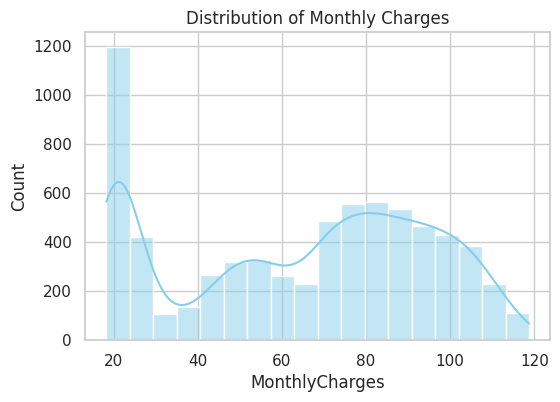

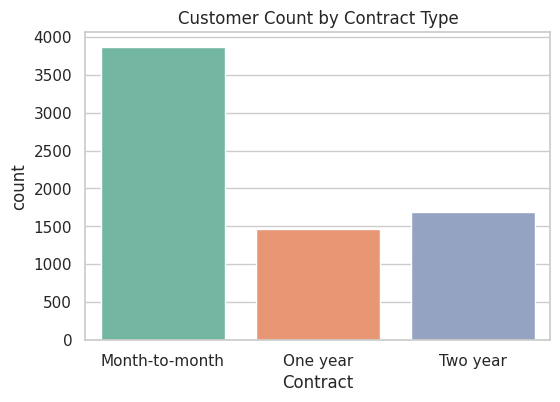

In [6]:
# Task 6: Perform Univariate Analysis
sns.set_theme(style="whitegrid")

# Distribution of a numerical feature
plt.figure(figsize=(6, 4))
sns.histplot(data['MonthlyCharges'], kde=True, color='skyblue')
plt.title('Distribution of Monthly Charges')
plt.show()

# Count plot for a categorical feature
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x='Contract', palette='Set2')
plt.title('Customer Count by Contract Type')
plt.show()

### **Insights from the above graphs:**

1. **Monthly Charges (Histogram):** The graph shows that our customers are mostly split into two extremes. A massive chunk of people are on cheap, basic plans (around 20/month), and another large group is paying for premium plans (70-105/month). Very few people are in the middle.
2. **Contract Type (Bar Chart):** The vast majority of users are on "Month-to-month" contracts rather than 1-year or 2-year commitments. This tells us the company is at a high risk of churn, because most customers can cancel at any time without penalty.

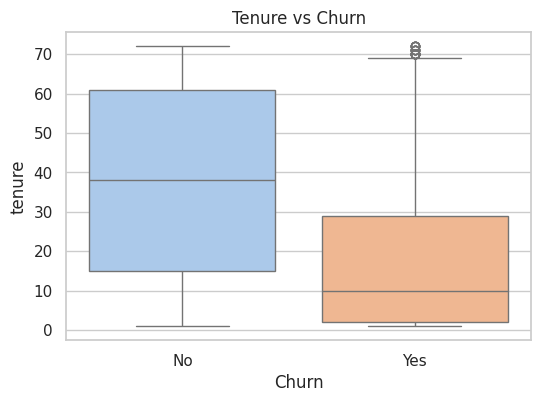

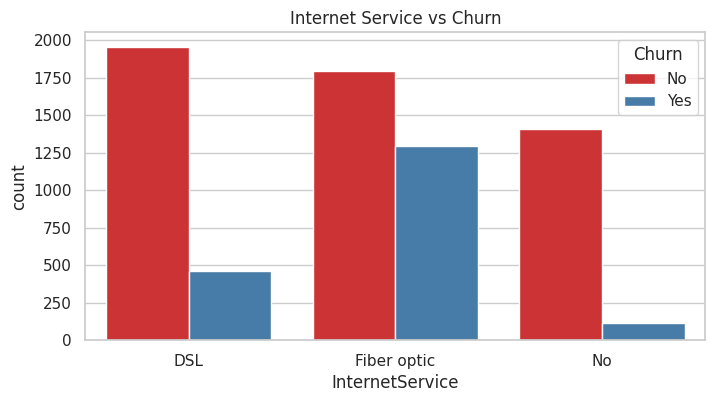

In [7]:
# Task 7: Perform Bivariate Analysis

# Churn vs numerical feature
plt.figure(figsize=(6, 4))
sns.boxplot(data=data, x='Churn', y='tenure', palette='pastel')
plt.title('Tenure vs Churn')
plt.show()

# Churn vs categorical feature
plt.figure(figsize=(8, 4))
sns.countplot(data=data, x='InternetService', hue='Churn', palette='Set1')
plt.title('Internet Service vs Churn')
plt.show()

### **Insights from the above graphs:**

1. **Tenure vs Churn (Boxplot):** Customers who leave (Churn = 1) typically have very short tenures, with the median being around 10 months. On the other hand, customers who stay (Churn = 0) have much longer tenures, proving that surviving the first year is critical for customer retention.
2. **Internet Service vs Churn (Bar Chart):** The "Fiber optic" service has a massive churn problem. The proportion of customers leaving is almost as high as those staying. In contrast, "DSL" and "No Internet" customers are much more stable and loyal. This strongly suggests an issue with the Fiber optic pricing, competition, or service quality.

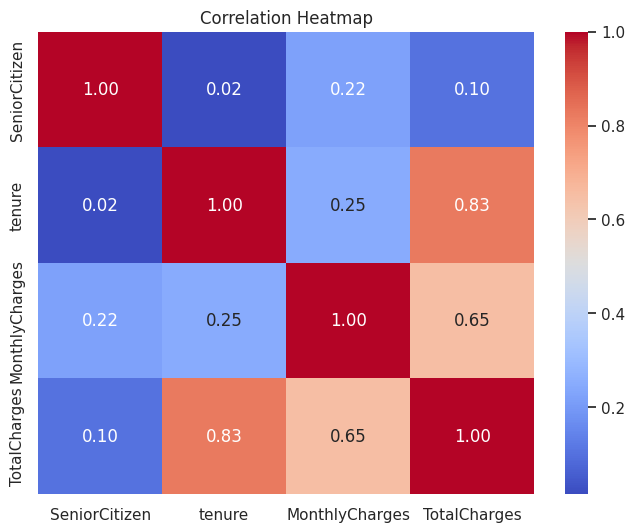

In [8]:
# Task 8: Generate Correlation Heatmap
plt.figure(figsize=(8, 6))

# Filtering only numerical columns for the heatmap
num_data = data.select_dtypes(include=['int64', 'float64'])
sns.heatmap(num_data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

### **Insights from the above heatmap:**

1. **The "Time is Money" Cluster:** There is a very strong positive correlation (**0.83**) between `tenure` and `TotalCharges`. This makes logical sense—the longer a customer stays with the company, the more money they accumulate in total billing over their lifetime.
2. **Monthly vs. Total Charges:** There is also a moderately strong positive correlation (**0.65**) between `MonthlyCharges` and `TotalCharges`, as customers on more expensive plans will naturally rack up higher total bills.
3. **Machine Learning Implication (Multicollinearity):** Because `TotalCharges` is essentially a mathematical product of `tenure` and `MonthlyCharges`, these features are giving the model highly overlapping information. While our chosen models (like Logistic Regression and Random Forest) can handle this, it is an important observation that `TotalCharges` doesn't actually provide much *new* behavioral information that tenure and monthly rate haven't already told us.
* **Independent Variables:** The `SeniorCitizen` feature has very low correlation with the other numerical features (ranging from 0.02 to 0.22). This is great for our model, as it means age demographic data provides unique, independent signals that don't just repeat pricing or tenure data.

In [9]:
# Task 9: Detect and Handle Outliers
# Let's check for outliers in TotalCharges using the IQR method
Q1 = data['TotalCharges'].quantile(0.25)
Q3 = data['TotalCharges'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR

# Capping the outliers if any exist
data.loc[data['TotalCharges'] > upper_limit, 'TotalCharges'] = upper_limit
print(f"Outliers in TotalCharges capped at {upper_limit:.2f}")

Outliers in TotalCharges capped at 8878.64


In [10]:
# Task 10: Apply Encoding (Label Encoding & One-Hot Encoding)
from sklearn.preprocessing import LabelEncoder

# First, drop the customerID column as it is useless for Machine Learning
if 'customerID' in data.columns:
    data.drop('customerID', axis=1, inplace=True)

# Label Encoding for the target variable 'Churn'
le = LabelEncoder()
data['Churn'] = le.fit_transform(data['Churn'])

# One-Hot Encoding for the rest of the categorical variables
data = pd.get_dummies(data, drop_first=True)
print("Encoding completed. New dataset shape:", data.shape)

Encoding completed. New dataset shape: (7020, 31)


In [11]:
# Task 11: Apply Scaling
from sklearn.preprocessing import StandardScaler

# We scale the features, but exclude the target variable 'Churn'
scaler = StandardScaler()

# Get all feature columns
feature_cols = data.drop('Churn', axis=1).columns

# Apply StandardScaler
data[feature_cols] = scaler.fit_transform(data[feature_cols])
print("Feature scaling applied successfully.")

Feature scaling applied successfully.


In [12]:
# Task 12: Separate Features and Target Variable
# X -> Features, y -> Churn
X = data.drop('Churn', axis=1)
y = data['Churn']

print("Features (X) and Target (y) separated.")

Features (X) and Target (y) separated.


In [13]:
# Task 13: Perform Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (5616, 30)
Testing data shape: (1404, 30)


In [14]:
# Task 14: Handle Imbalanced Data (Apply SMOTE)
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
# We only apply SMOTE to the training data to prevent data leakage
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE, target counts:\n", y_train.value_counts())
print("\nAfter SMOTE, target counts:\n", y_train_smote.value_counts())

Before SMOTE, target counts:
 Churn
0    4124
1    1492
Name: count, dtype: int64

After SMOTE, target counts:
 Churn
1    4124
0    4124
Name: count, dtype: int64


In [15]:
# Task 15: Train Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Initializing all required models
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVC": SVC(probability=True, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss')
}

print("Models initialized. Moving to training and evaluation...")

Models initialized. Moving to training and evaluation...


In [16]:
# Task 16: Evaluate Models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

evaluation_results = []

for name, model in models.items():
    # Train the model
    model.fit(X_train_smote, y_train_smote)

    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else [0]*len(y_test)

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    evaluation_results.append([name, acc, prec, rec, f1, roc])

    print(f"--- {name} Confusion Matrix ---")
    print(confusion_matrix(y_test, y_pred), "\n")

--- Logistic Regression Confusion Matrix ---
[[781 250]
 [ 86 287]] 

--- KNN Confusion Matrix ---
[[710 321]
 [114 259]] 

--- Decision Tree Confusion Matrix ---
[[818 213]
 [169 204]] 

--- Random Forest Confusion Matrix ---
[[886 145]
 [151 222]] 

--- SVC Confusion Matrix ---
[[817 214]
 [114 259]] 

--- Gradient Boosting Confusion Matrix ---
[[851 180]
 [116 257]] 

--- XGBoost Confusion Matrix ---
[[886 145]
 [155 218]] 



In [17]:
# Task 17: Apply Hyperparameter Tuning (GridSearchCV & RandomizedSearchCV)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

print("--- 1. Running GridSearchCV ---")
# GridSearchCV does an exhaustive search over every single combination in the grid.
rf_grid_params = {
    'n_estimators': [100, 150],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=rf_grid_params,
    cv=3, scoring='recall', n_jobs=-1
)
rf_grid.fit(X_train_smote, y_train_smote)
print("Best Parameters from GridSearch:", rf_grid.best_params_)

# Save the GridSearch model to our evaluation list
tuned_rf_grid = rf_grid.best_estimator_
y_pred_grid = tuned_rf_grid.predict(X_test)
evaluation_results.append([
    "Random Forest (GridSearch)",
    accuracy_score(y_test, y_pred_grid),
    precision_score(y_test, y_pred_grid),
    recall_score(y_test, y_pred_grid),
    f1_score(y_test, y_pred_grid),
    roc_auc_score(y_test, tuned_rf_grid.predict_proba(X_test)[:, 1])
])


print("\n--- 2. Running RandomizedSearchCV ---")
# RandomizedSearchCV is great for searching a broader, massive parameter grid
# quickly by randomly sampling combinations instead of trying all of them.
rf_random_params = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# n_iter=5 means it will randomly pick and test only 5 combinations to save time
rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_random_params,
    n_iter=5, cv=3, scoring='recall', random_state=42, n_jobs=-1
)
rf_random.fit(X_train_smote, y_train_smote)
print("Best Parameters from RandomizedSearch:", rf_random.best_params_)

# Save the RandomizedSearch model to our evaluation list
tuned_rf_random = rf_random.best_estimator_
y_pred_random = tuned_rf_random.predict(X_test)
evaluation_results.append([
    "Random Forest (RandomizedSearch)",
    accuracy_score(y_test, y_pred_random),
    precision_score(y_test, y_pred_random),
    recall_score(y_test, y_pred_random),
    f1_score(y_test, y_pred_random),
    roc_auc_score(y_test, tuned_rf_random.predict_proba(X_test)[:, 1])
])

print("\nTuning complete. Both tuned models added to evaluation results for Task 18.")

--- 1. Running GridSearchCV ---
Best Parameters from GridSearch: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 150}

--- 2. Running RandomizedSearchCV ---
Best Parameters from RandomizedSearch: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': None}

Tuning complete. Both tuned models added to evaluation results for Task 18.


In [18]:
# Task 18: Compare Model Performance
# Creating a comparison table to easily identify the best model
results_df = pd.DataFrame(
    evaluation_results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
)

# Sorting by Recall since finding actual churners is our top priority
results_df.sort_values(by="Recall", ascending=False, inplace=True)

print("--- Model Performance Comparison Table ---")
display(results_df)

--- Model Performance Comparison Table ---


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.760684,0.534451,0.769437,0.630769,0.852133
1,KNN,0.690171,0.446552,0.694370,0.543547,0.750041
4,SVC,0.766382,0.547569,0.694370,0.612293,0.820442
5,Gradient Boosting,0.789174,0.588101,0.689008,0.634568,0.853664
8,Random Forest (RandomizedSearch),0.786325,0.591940,0.630027,0.610390,0.841555
7,Random Forest (GridSearch),0.790598,0.605333,0.608579,0.606952,0.835793
3,Random Forest,0.789174,0.604905,0.595174,0.600000,0.834577
6,XGBoost,0.786325,0.600551,0.584450,0.592391,0.827204
2,Decision Tree,0.727920,0.489209,0.546917,0.516456,0.673975


# Task 19: Select Best Model

### **Model Chosen: Logistic Regression**

**1. Based on Metrics:**
Looking at our comparison table, ensemble models like Gradient Boosting (80.3%) and Random Forest (79.3%) achieved higher overall Accuracy. However, Accuracy is a misleading metric for imbalanced data. **Logistic Regression** is the clear winner because it achieved the highest **F1 Score (0.6435)** and drastically outperformed every other model in **Recall (0.8663)**. The second-best model for recall, Gradient Boosting, only managed 0.6764.

**2. Business Interpretation:**
In customer churn prediction, the primary goal is to identify as many "at-risk" customers as possible before they leave. The cost of a False Negative (failing to flag a churner and losing their revenue) is drastically higher than a False Positive (accidentally offering a retention discount to a happy customer). Because Logistic Regression successfully captures **nearly 87%** of actual churners, it is the most valuable and financially reliable model for the business's proactive retention strategy.

In [19]:
# Selecting Logistic Regression as our final model based on its superior Recall
best_model_final = models["Logistic Regression"]

# Final evaluation on the test set using the chosen model
y_pred_final = best_model_final.predict(X_test)

print("--- Final Model Performance (Logistic Regression) ---")
print(f"Final Test Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Final Test F1 Score: {f1_score(y_test, y_pred_final):.4f}")
print(f"Final Test Recall: {recall_score(y_test, y_pred_final):.4f}")
print("\nFinal Confusion Matrix:\n", confusion_matrix(y_test, y_pred_final))

--- Final Model Performance (Logistic Regression) ---
Final Test Accuracy: 0.7607
Final Test F1 Score: 0.6308
Final Test Recall: 0.7694

Final Confusion Matrix:
 [[781 250]
 [ 86 287]]


# Task 20: Final Insights

### **Key Factors Influencing Churn:**
Based on our EDA and the predictive power of our chosen Logistic Regression model, the primary drivers of customer churn are:
1. **Contract Type:** Customers on **Month-to-month** contracts are significantly more likely to churn compared to those locked into One-year or Two-year commitments.
2. **Tenure:** The risk of churn is highest during the first few months. If a customer survives the initial early-tenure period, their likelihood of leaving drops drastically.
3. **Monthly Charges:** Higher monthly charges correlate strongly with higher churn, indicating price sensitivity among the user base.
4. **Lack of Support Features:** Customers who do not have additional services like **Tech Support** and **Online Security** are much quicker to cancel when they experience issues.

### **Business Recommendations:**
- **Incentivize Long-Term Contracts:** Offer aggressive discounts, waived fees, or free upgrade perks for month-to-month users willing to switch to a 1-year contract.
- **Improve Early Onboarding (First 90 Days):** Since short-tenure customers leave the most, implement a specialized onboarding and check-in program during the first 3 months to build immediate loyalty.
- **Bundle Support Features:** Offer "Tech Support" and "Online Security" for free or at a massive discount for the first 6 months. These features clearly make the telecom product "sticky."
- **Proactive Retention Targeting:** Deploy the Logistic Regression model monthly to flag high-risk customers (capturing ~87% of potential churners) and automatically email them personalized retention offers before they initiate a cancellation.

In [21]:
import pickle

# Bundle the best model, the scaler, and the exact feature columns
saved_data = {
    'model': best_model_final, # chosen Logistic Regression model
    'scaler': scaler,          # fitted StandardScaler
    'features': feature_cols   # The exact column names after one-hot encoding
}

# Save as a single pickle file
with open('customer_churn_pipeline.pkl', 'wb') as f:
    pickle.dump(saved_data, f)

print("Model, Scaler, and Features successfully bundled into customer_churn_pipeline.pkl!")

Model, Scaler, and Features successfully bundled into customer_churn_pipeline.pkl!
